In [1]:
# 导入必要的库
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from scipy.signal import butter, filtfilt

# 设置科研绘图风格
plt.style.use('seaborn-v0_8-paper')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['legend.fontsize'] = 10
plt.rcParams['figure.dpi'] = 100

print("Libraries imported and style set.")

Libraries imported and style set.


In [2]:
# 读取数据
input_path = '../../DataFormat/merged_cgm_data.csv'
print(f"Reading data from: {input_path}")

if os.path.exists(input_path):
    df = pd.read_csv(input_path)
    df['time'] = pd.to_datetime(df['time'])
    print(f"Data loaded successfully. Shape: {df.shape}")
    print(f"Columns: {df.columns.tolist()}")
    print(f"Unique subjects: {df['id'].nunique()}")
else:
    print(f"Error: File not found at {input_path}")

Reading data from: ../../DataFormat/merged_cgm_data.csv
Data loaded successfully. Shape: (101600, 5)
Columns: ['id', 'time', 'gl', 'age', 'bmi']
Unique subjects: 168


In [3]:
# 定义巴特沃斯滤波函数
def apply_butterworth_filter(data, order=2, cutoff=0.1):
    """
    应用巴特沃斯低通滤波器 (双向滤波以消除相位滞后)
    
    参数:
    data: 输入数据数组
    order: 滤波器阶数。2阶通常足够。
    cutoff: 归一化截止频率 (0 to 1, where 1 is Nyquist frequency)。
            采样间隔 T = 5 min
            Nyquist freq = 1 / (2*T) = 0.1 cycles/min
            如果我们要滤除周期小于 60 min 的噪声:
            Cutoff freq fc = 1/60 cycles/min
            Normalized Wn = fc / Nyquist = (1/60) / (1/10) = 10/60 ≈ 0.16
    """
    if len(data) < 15: # 数据太短
        return data
    
    # 设计滤波器
    # b, a 是滤波器系数
    b, a = butter(order, cutoff, btype='low')
    
    # 应用零相位滤波 (filtfilt)
    # filtfilt 会正向滤波一次，然后反向滤波一次，从而消除相位延迟
    try:
        y = filtfilt(b, a, data)
        return y
    except Exception as e:
        print(f"Filtering failed: {e}")
        return data

print("Butterworth Filter function defined.")

Butterworth Filter function defined.


In [4]:
# 应用巴特沃斯滤波
print("Applying Butterworth Filter to all subjects...")

# 参数设置
ORDER = 2
# 截止频率设置：保留周期大于 ~50-60 分钟的信号
# Wn = 0.15 对应约 66 分钟的周期 (1/(0.15 * 0.1))
CUTOFF = 0.15 

filtered_dfs = []
unique_subjects = sorted(df['id'].unique())

for subject_id in unique_subjects:
    # 获取该受试者数据
    subject_data = df[df['id'] == subject_id].sort_values('time').copy()
    
    # 处理缺失值：移除 gl 为 NaN 的行
    subject_data = subject_data.dropna(subset=['gl'])
    
    if subject_data.empty:
        continue
    
    # 执行滤波
    gl_values = subject_data['gl'].values
    filtered_values = apply_butterworth_filter(gl_values, order=ORDER, cutoff=CUTOFF)
    
    # 保存结果
    subject_data['gl_butter'] = filtered_values
    
    # 计算残差 (Residuals)
    subject_data['residual'] = subject_data['gl'] - subject_data['gl_butter']
    
    filtered_dfs.append(subject_data)

# 合并结果
df_filtered = pd.concat(filtered_dfs, ignore_index=True)

print("Filtering complete.")
print(f"Filtered data shape: {df_filtered.shape}")
df_filtered.head()

Applying Butterworth Filter to all subjects...
Filtering complete.
Filtered data shape: (101596, 7)


,id,time,gl,age,bmi,gl_butter,residual
0,2,2012-01-01 00:00:00,167.0,42.0,30.0,166.909051,0.090949
1,2,2012-01-01 00:05:00,163.0,42.0,30.0,160.978605,2.021395
2,2,2012-01-01 00:10:00,158.0,42.0,30.0,155.031165,2.968835
3,2,2012-01-01 00:15:00,151.0,42.0,30.0,149.137821,1.862179
4,2,2012-01-01 00:20:00,144.0,42.0,30.0,143.482466,0.517534


Generating plots for 10 subjects


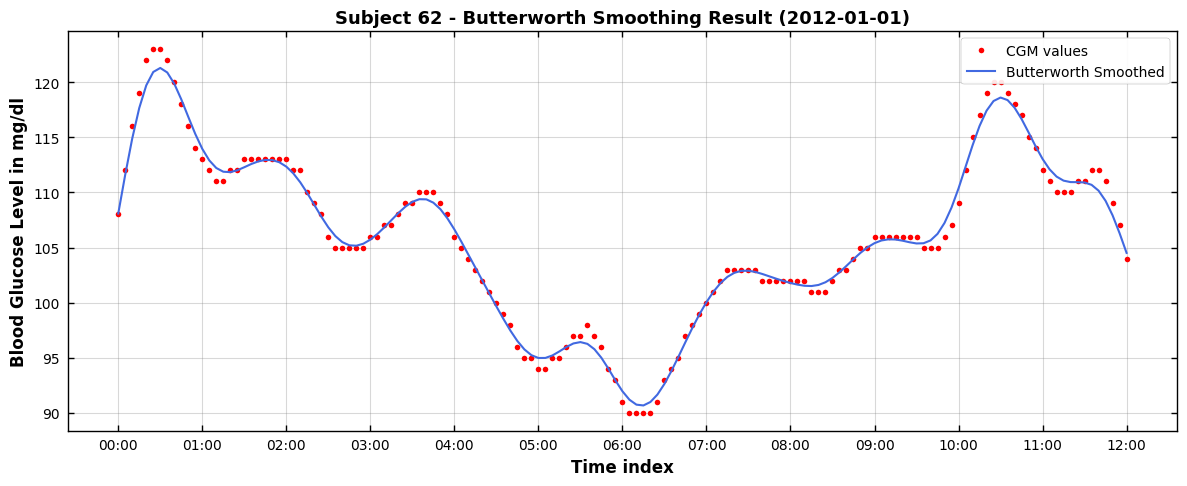

Visualization for Subject 62 generated.


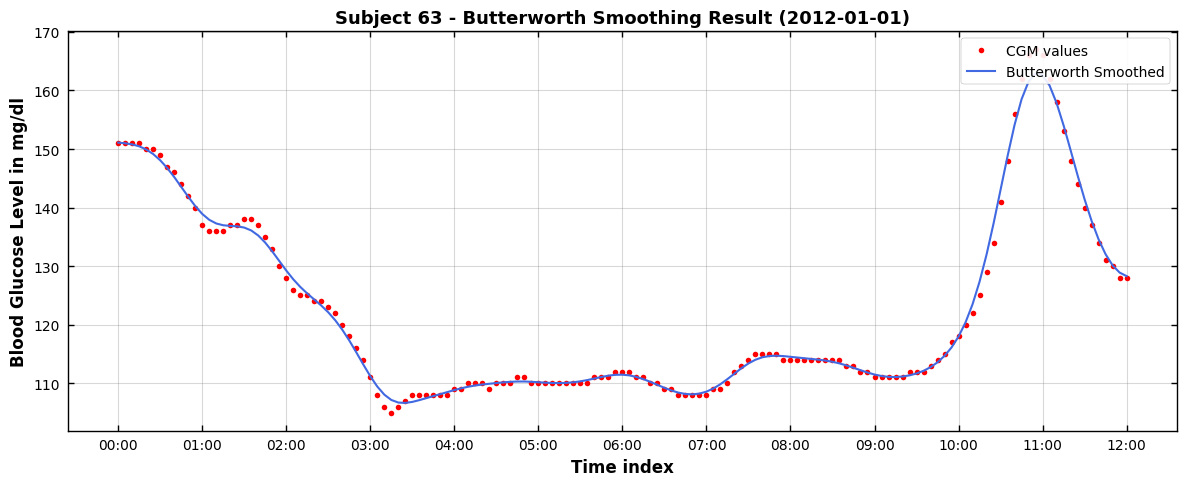

Visualization for Subject 63 generated.


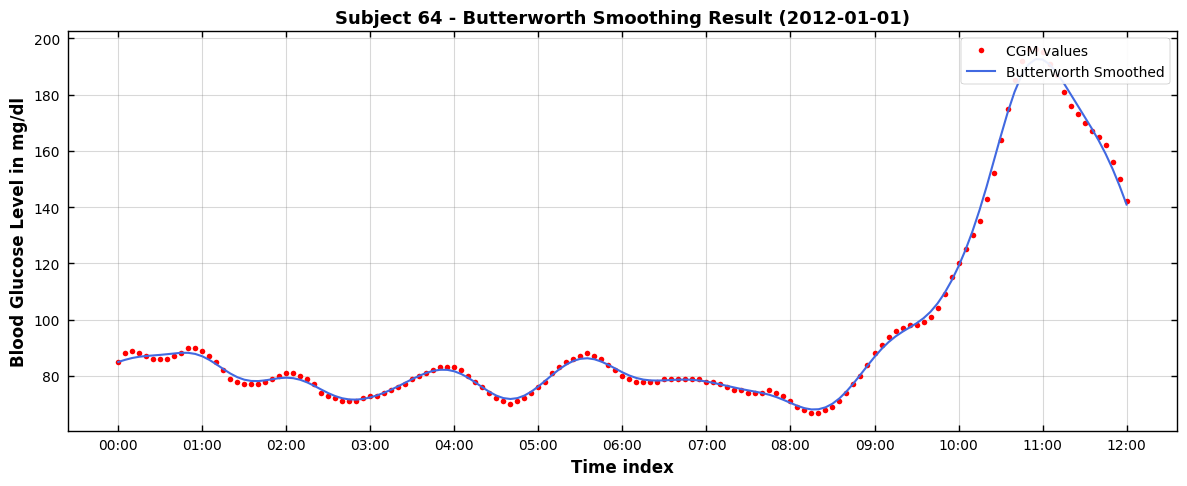

Visualization for Subject 64 generated.


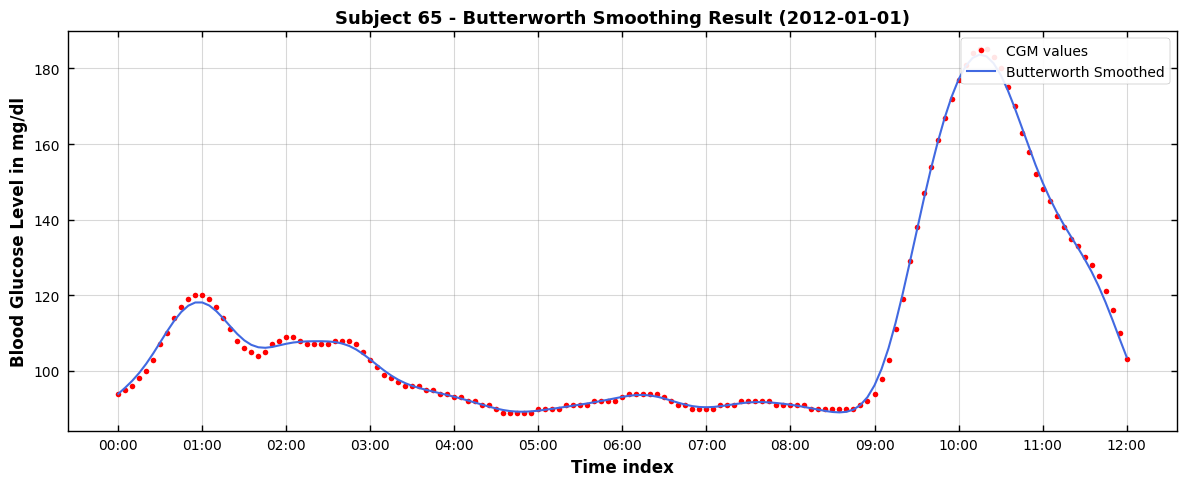

Visualization for Subject 65 generated.


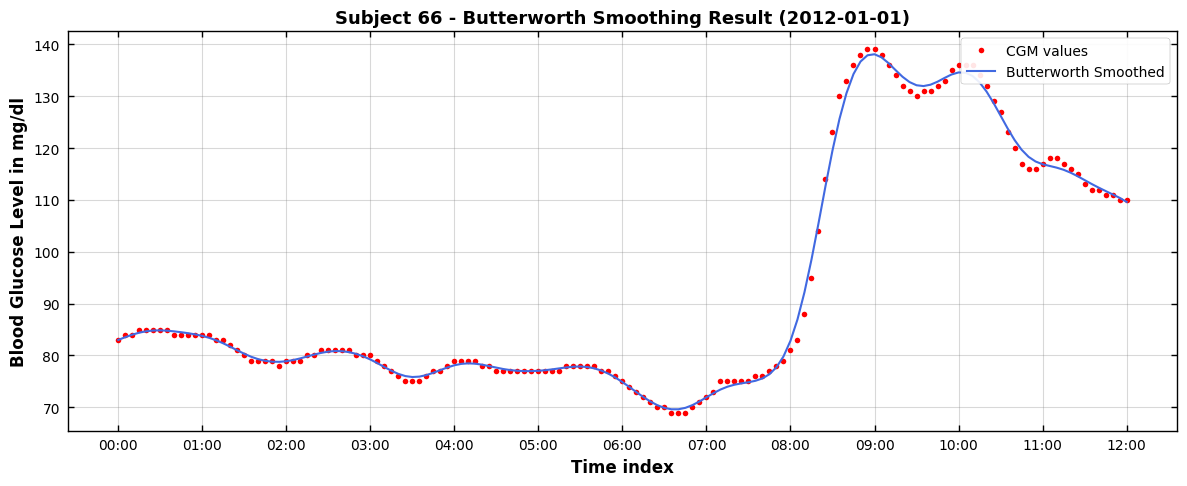

Visualization for Subject 66 generated.


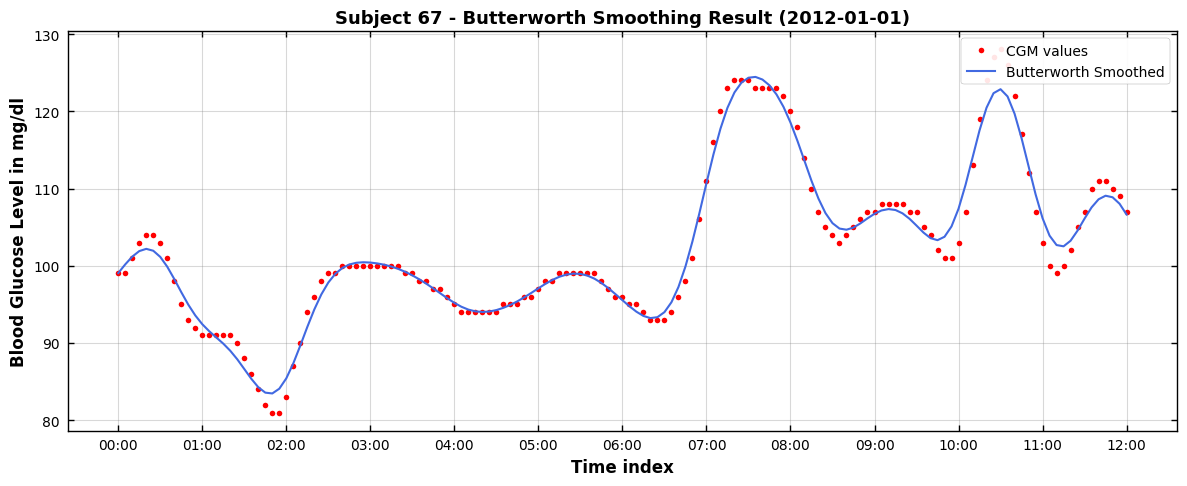

Visualization for Subject 67 generated.


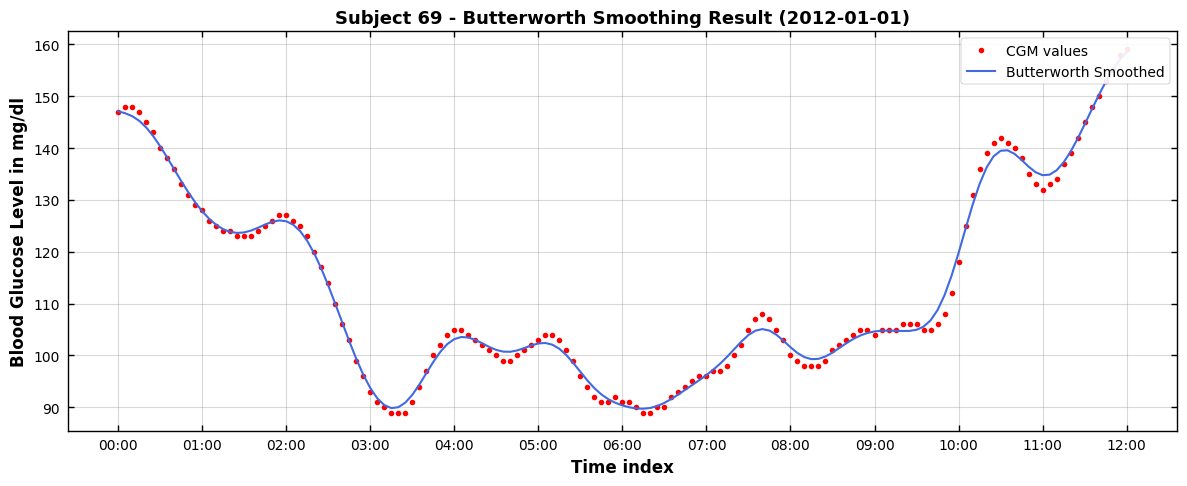

Visualization for Subject 69 generated.


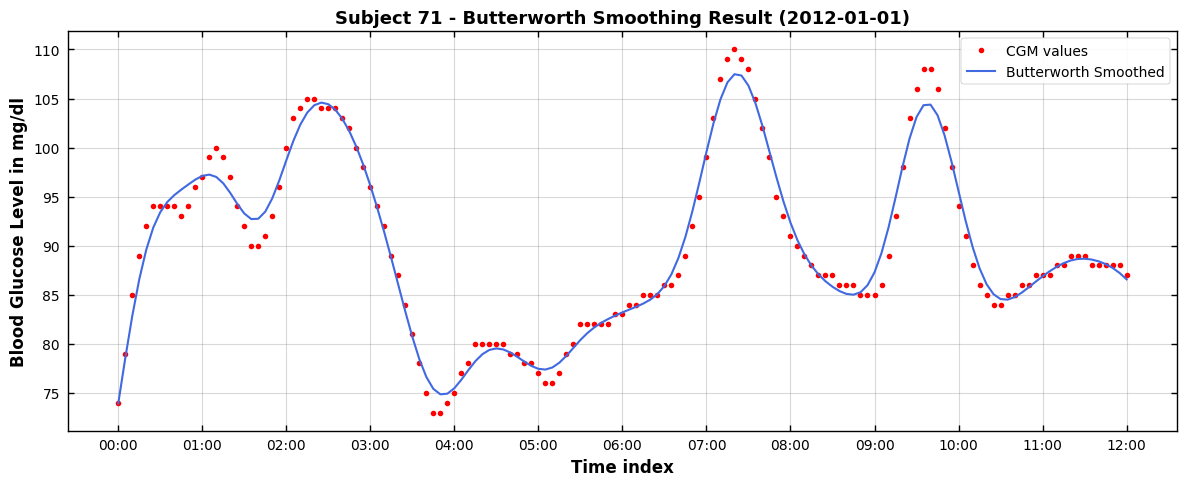

Visualization for Subject 71 generated.


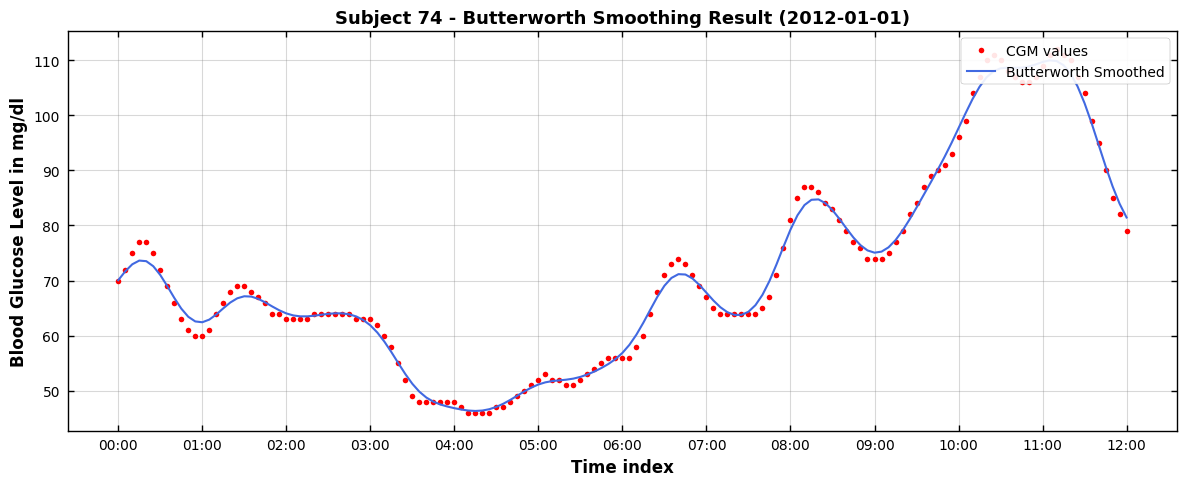

Visualization for Subject 74 generated.


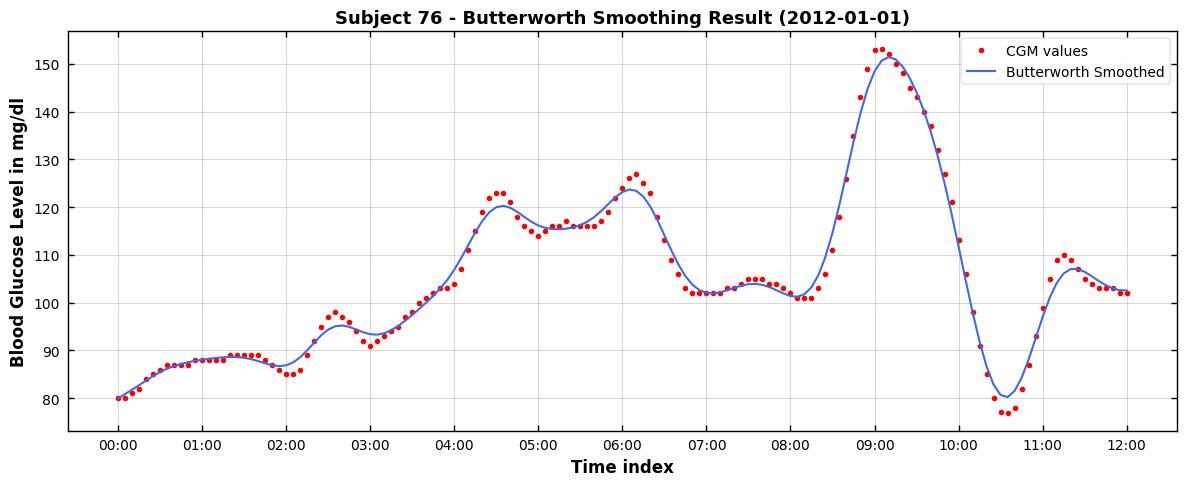

Visualization for Subject 76 generated.


In [5]:
# 可视化对比 (仿照参考图风格)
# 选择前3个受试者进行展示
subjects_to_plot = unique_subjects[50:60]

print(f"Generating plots for {len(subjects_to_plot)} subjects")

for i, subject_id in enumerate(subjects_to_plot):
    subject_data = df_filtered[df_filtered['id'] == subject_id].copy()
    
    # 找到数据点最多的一天
    subject_data['date'] = subject_data['time'].dt.date
    if subject_data.empty:
        continue
        
    best_date = subject_data['date'].value_counts().idxmax()
    full_day_data = subject_data[subject_data['date'] == best_date].sort_values('time')
    
    # 截取12小时的数据进行展示
    if not full_day_data.empty:
        start_time = full_day_data['time'].iloc[0]
        end_time = start_time + pd.Timedelta(hours=12)
        plot_data = full_day_data[(full_day_data['time'] >= start_time) & (full_day_data['time'] <= end_time)]
    else:
        plot_data = full_day_data

    if plot_data.empty:
        continue
    
    # 创建图表 - 单个图 (仿照论文风格)
    plt.figure(figsize=(12, 5))
    
    # 绘制原始数据 (红点)
    plt.plot(plot_data['time'], plot_data['gl'], '.', color='red', markersize=8, label='CGM values')
    
    # 绘制滤波数据 (蓝线)
    plt.plot(plot_data['time'], plot_data['gl_butter'], '-', color='royalblue', linewidth=1.5, label='Butterworth Smoothed')
    
    # 设置标签和标题
    plt.ylabel('Blood Glucose Level in mg/dl', fontweight='bold')
    plt.xlabel('Time index', fontweight='bold')
    plt.title(f'Subject {subject_id} - Butterworth Smoothing Result ({best_date})', fontweight='bold')
    
    # 设置图例 (右上角，带边框)
    plt.legend(loc='upper right', frameon=True, framealpha=0.9, edgecolor='gray')
    
    # 设置网格 (向内刻度)
    plt.grid(True, alpha=0.3, linestyle='-', color='gray')
    
    # 格式化时间轴
    import matplotlib.dates as mdates
    ax = plt.gca()
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M')) # 仅显示小时:分钟
    ax.xaxis.set_major_locator(mdates.HourLocator(interval=1))
    
    # 设置边框和刻度样式
    for spine in ax.spines.values():
        spine.set_linewidth(1.0)
        spine.set_color('black')
        
    plt.tick_params(direction='in', length=4, width=1, colors='black', top=True, right=True)
    
    plt.tight_layout()
    plt.show()
    
    print(f"Visualization for Subject {subject_id} generated.")

In [6]:
# 导出滤波后的数据
output_file = 'butterworth_filtered_cgm_data.csv'
print(f"Exporting filtered data to: {output_file}")

# 选择要导出的列
export_cols = ['id', 'time', 'gl_butter', 'age', 'bmi']
df_export = df_filtered[export_cols]

# 导出
df_export.to_csv(output_file, index=False)

print("Export complete.")
print(f"File saved: {os.path.abspath(output_file)}")
df_export.head()

Exporting filtered data to: butterworth_filtered_cgm_data.csv
Export complete.
File saved: c:\Users\江一骏\Desktop\学习\HKU\dissertation\engineering\code\GlucosePrediction\src\DataFillter\butterworth\butterworth_filtered_cgm_data.csv


,id,time,gl_butter,age,bmi
0,2,2012-01-01 00:00:00,166.909051,42.0,30.0
1,2,2012-01-01 00:05:00,160.978605,42.0,30.0
2,2,2012-01-01 00:10:00,155.031165,42.0,30.0
3,2,2012-01-01 00:15:00,149.137821,42.0,30.0
4,2,2012-01-01 00:20:00,143.482466,42.0,30.0


## 总结

1.  **巴特沃斯滤波**: 成功应用双向巴特沃斯低通滤波器 (Order=2, Cutoff=0.15)。
2.  **效果**: 有效去除了高频噪声，且由于使用了 `filtfilt`，没有引入相位延迟。
3.  **数据导出**: 结果已保存至 `butterworth_filtered_cgm_data.csv`。